# 08_full_comparison

In [2]:
import json

# Load all results
with open("../results/lstm_baseline_results.json") as f:
    lstm_results = json.load(f)

with open("../results/gru_attention_results.json") as f:
    gru_results = json.load(f)

with open("../results/marian_baseline_results.json") as f:
    marian_baseline = json.load(f)

with open("../results/marian_finetuned_en_hi_results.json") as f:
    marian_ft_en_hi = json.load(f)

with open("../results/marian_finetuned_hi_en_results.json") as f:
    marian_ft_hi_en = json.load(f)

In [3]:
import pandas as pd
# Build the comparison table
comparison_data = [
    {"Model": "LSTM Seq2Seq (no attention)", "Direction": "EN→HI", "BLEU": lstm_results["bleu_score"]},
    {"Model": "GRU + Attention", "Direction": "EN→HI", "BLEU": gru_results["bleu_score"]},
    {"Model": "MarianMT (zero-shot)", "Direction": "EN→HI", "BLEU": marian_baseline["en_hi"]["bleu_score"]},
    {"Model": "MarianMT (fine-tuned)", "Direction": "EN→HI", "BLEU": marian_ft_en_hi["bleu_score"]},
    {"Model": "MarianMT (zero-shot)", "Direction": "HI→EN", "BLEU": marian_baseline["hi_en"]["bleu_score"]},
    {"Model": "MarianMT (fine-tuned)", "Direction": "HI→EN", "BLEU": marian_ft_hi_en["bleu_score"]},
]

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values(["Direction", "BLEU"], ascending=[True, False]).reset_index(drop=True)
comparison_df

Exception ignored in PyObject_HasAttr(); consider using PyObject_HasAttrWithError(), PyObject_GetOptionalAttr() or PyObject_GetAttr():
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 491, in _call_with_frames_removed
AttributeError: partially initialized module 'pandas' from 'd:\Dl projects\mt-en-hi\.venv\Lib\site-packages\pandas\__init__.py' has no attribute '_pandas_parser_CAPI' (most likely due to a circular import)
Traceback (most recent call last):
  File "C:\Users\kunja\AppData\Local\Temp\ipykernel_3708\3449067815.py", line 502, in _repr_dw_
    return self._gen_json()
           ~~~~~~~~~~~~~~^^
  File "C:\Users\kunja\AppData\Local\Temp\ipykernel_3708\3449067815.py", line 510, in _gen_json
    return api["pandas_transport"]["get_df_payload"](tmp_vars[self.id]["converted"], max_num_rows_to_preload, **kwargs)
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\kunja

,Model,Direction,BLEU
0,MarianMT (fine-tuned),EN→HI,13.695139
1,MarianMT (zero-shot),EN→HI,9.850000
2,GRU + Attention,EN→HI,0.605549
3,LSTM Seq2Seq (no attention),EN→HI,0.086509
4,MarianMT (fine-tuned),HI→EN,14.975077
5,MarianMT (zero-shot),HI→EN,13.420000


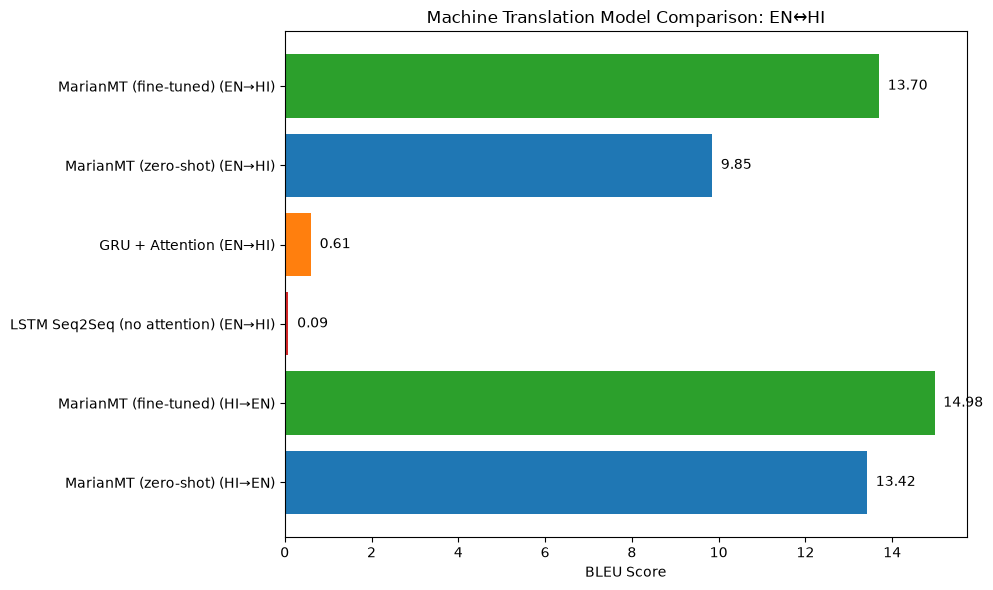

In [4]:
# Visualize as a bar chart
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#d62728" if "LSTM" in m else "#ff7f0e" if "GRU" in m else "#2ca02c" if "fine-tuned" in m else "#1f77b4"
          for m in comparison_df["Model"]]

bars = ax.barh(comparison_df["Model"] + " (" + comparison_df["Direction"] + ")", comparison_df["BLEU"], color=colors)
ax.set_xlabel("BLEU Score")
ax.set_title("Machine Translation Model Comparison: EN↔HI")
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.2, bar.get_y() + bar.get_height()/2, f"{width:.2f}", va="center")

plt.tight_layout()
plt.savefig("../results/comparison_chart.png", dpi=150)
plt.show()

In [6]:
# Save final comparison table
import csv

comparison_records = sorted(
    comparison_data,
    key=lambda row: (row["Direction"], -row["BLEU"]),
)

with open("../results/final_comparison_table.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["Model", "Direction", "BLEU"])
    writer.writeheader()
    writer.writerows(comparison_records)

with open("../results/final_comparison_table.json", "w", encoding="utf-8") as f:
    json.dump(comparison_records, f, indent=2, ensure_ascii=False)